#  <span style="color:red">ASMAE AIT OUALI</span>


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# On lit le fichier CSV contenant les données publicitaires
# Ce dataset contient généralement les dépenses en publicité (TV, radio, journal)
# et les ventes associées.
df = pd.read_csv("advertising.csv")

# Afficher les 10 premières lignes pour comprendre la structure des données
# Cela permet de vérifier que les colonnes sont bien chargées
df.head(10)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,15.6


#  <span style="color:blue">Régression linéaire simple FROM SCRATCH</span>


In [40]:
#  Régression Linéaire Simple FROM SCRATCH
# X : variable explicative (input) : budget TV
# y : variable cible (output) : ventes
# .values permet de convertir en tableau NumPy (plus rapide pour les calculs)
X = df["TV"].values
y = df["Sales"].values

#  Split Train / Test (80% / 20%) 

# On fixe une seed pour que le mélange soit reproductible
# (important pour avoir toujours les mêmes résultats)
np.random.seed(42)
# Création d’un tableau d’indices (0, 1, 2, ..., n-1)
indices = np.arange(len(X))
# Mélange aléatoire des indices
np.random.shuffle(indices)
# Définir le point de séparation (80% pour train, 20% pour test)
split = int(0.8 * len(X))

# Séparation des données :
# Train = données pour apprendre le modèle
# Test  = données pour évaluer le modèle
X_train, X_test = X[indices[:split]], X[indices[split:]]
y_train, y_test = y[indices[:split]], y[indices[split:]]
print(f"Train : {len(X_train)} exemples | Test : {len(X_test)} exemples")

Train : 160 exemples | Test : 40 exemples


In [41]:
#  Calculer b1 et b0 (formules MCO) 
#
#         Σ (xi - x̄)(yi - ȳ)
#   b1 = ───────────────────
#             Σ (xi - x̄)²
#
#   b0 = ȳ - b1 * x̄

# On implémente ici la régression linéaire SIMPLE  FROM SCRATCH
# en utilisant les formules mathématiques

# Formules :
# b1 = covariance(X, y) / variance(X)
# b0 = moyenne(y) - b1 * moyenne(X)

# Calcul des moyennes
x_mean = np.mean(X_train)
y_mean = np.mean(y_train)

# Calcul de la pente (b1)
# Numérateur = covariance
# Dénominateur = variance de X
b1 = np.sum((X_train - x_mean) * (y_train - y_mean)) / np.sum((X_train - x_mean) ** 2)

# Calcul de l'intercept (b0)
b0 = y_mean - b1 * x_mean

# Affichage des résultats
print(f"\nb0 (intercept) = {b0:.4f}")
print(f"b1 (pente)     = {b1:.4f}")

# Équation finale du modèle :
# Sales = b0 + b1 * TV
print(f"Équation : Sales = {b0:.2f} + {b1:.2f} * TV")



b0 (intercept) = 7.0627
b1 (pente)     = 0.0547
Équation : Sales = 7.06 + 0.05 * TV


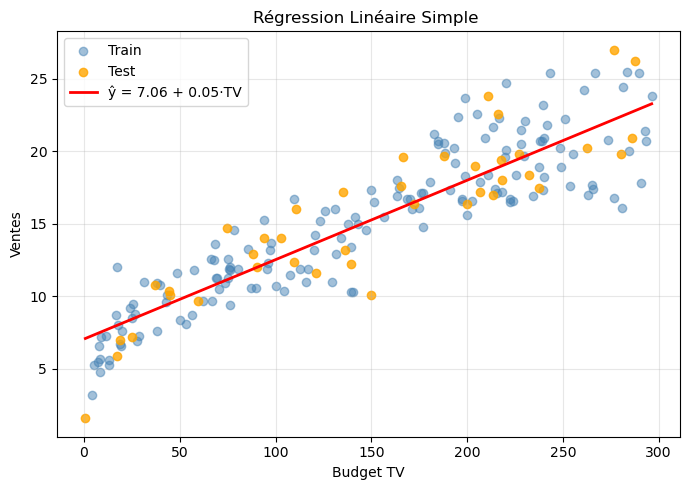

In [42]:
#  Visualisation 

# Création d'une ligne continue pour tracer la droite de régression
# np.linspace génère 300 points entre min(X) et max(X)
x_line = np.linspace(X.min(), X.max(), 300)

# Calcul des valeurs y correspondantes
y_line = b0 + b1 * x_line
# Création de la figure
plt.figure(figsize=(7, 5))
# Affichage des points d'entraînement
plt.scatter(X_train, y_train, color="steelblue", alpha=0.5, label="Train")
# Affichage des points de test
plt.scatter(X_test,  y_test,  color="orange", alpha=0.8, label="Test")
# Affichage de la droite de régression
plt.plot(x_line, y_line, color="red", linewidth=2,
         label=f"ŷ = {b0:.2f} + {b1:.2f}·TV")
# Labels des axes
plt.xlabel("Budget TV")
plt.ylabel("Ventes")

# Titre du graphique
plt.title("Régression Linéaire Simple ")

# Légende
plt.legend()

# Ajout d'une grille pour améliorer la lisibilité
plt.grid(alpha=0.3)

# Ajustement automatique des marges
plt.tight_layout()

plt.show()

#  <span style="color:blue">Régression multiple  FROM SCRATCH</span>


In [43]:
#  Régression Linéaire MULTIPLE FROM SCRATCH

# X : matrice des variables explicatives
# Chaque ligne = un exemple
# Chaque colonne = une variable (TV, Radio, Newspaper)
X = df[["TV", "Radio", "Newspaper"]].values   # shape (200, 3)
# y : vecteur cible (ventes)
y = df["Sales"].values                        # shape (200,)
# Exemple :
# X[0] = [TV, Radio, Newspaper]
# y[0] = Sales associée                        # shape (200,)
# Split Train / Test (80% / 20%)
# Fixer une seed pour garantir la reproductibilité
np.random.seed(42)
# Générer des indices (0 à n-1)
indices = np.arange(len(X))
# Mélanger aléatoirement les données
np.random.shuffle(indices)
# Définir la séparation 80% train / 20% test
split = int(0.8 * len(X))

# Séparer les données :
# Train = apprentissage du modèle
# Test  = évaluation du modèle
X_train, X_test = X[indices[:split]], X[indices[split:]]
y_train, y_test = y[indices[:split]], y[indices[split:]]

print(f"Train : {len(X_train)} exemples | Test : {len(X_test)} exemples")


Train : 160 exemples | Test : 40 exemples


In [44]:
#  Ajouter la colonne de 1 (biais b0)
#
#   On ajoute une colonne de 1 à gauche de X
#   pour que le calcul inclue b0 automatiquement
#
#   X_b = [ 1  TV  Radio  Newspaper ]

def ajouter_biais(X):
    # Créer une colonne de 1 (taille : nombre de lignes de X)
    ones = np.ones((X.shape[0], 1))
    
    # Concaténer horizontalement (à gauche)
    return np.hstack([ones, X])

# Appliquer sur train et test
X_train_b = ajouter_biais(X_train)
X_test_b  = ajouter_biais(X_test)


In [45]:
#  Calcul des coefficients (Équation Normale)

# Formule mathématique :
# β = (XᵀX)^(-1) Xᵀ y

# Où :
# Xᵀ = transpose de X
# (XᵀX)^(-1) = inverse de la matrice
# β = [b0, b1, b2, b3]

# Étapes du calcul :

# 1. XᵀX  → matrice de covariance
# 2. inverse(XᵀX)
# 3. multiplier par Xᵀ
# 4. multiplier par y

beta = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train
# Extraire les coefficients
b0, b1, b2, b3 = beta
print(f"Coefficients appris")
print(f"b0 (intercept)  = {b0:.4f}")
print(f"b1 (TV)         = {b1:.4f}")
print(f"b2 (Radio)      = {b2:.4f}")
print(f"b3 (Newspaper)  = {b3:.4f}")

# Équation finale du modèle
print(f"\nÉquation : Sales = {b0:.2f} + {b1:.2f}*TV + {b2:.2f}*Radio + {b3:.2f}*Newspaper")


# Prédictions
# Calcul matriciel :
# y_pred = X_test_b × β
# Chaque prédiction est une combinaison linéaire des variables
y_pred = X_test_b @ beta
# MSE (Mean Squared Error)
# mesure l'erreur moyenne entre les valeurs réelles et prédites
mse  = np.mean((y_test - y_pred) ** 2)
print(f"Résultats sur le Test")
print(f"MSE = {mse:.4f}")

Coefficients appris
b0 (intercept)  = 4.7438
b1 (TV)         = 0.0536
b2 (Radio)      = 0.1089
b3 (Newspaper)  = -0.0020

Équation : Sales = 4.74 + 0.05*TV + 0.11*Radio + -0.00*Newspaper
Résultats sur le Test
MSE = 3.5192


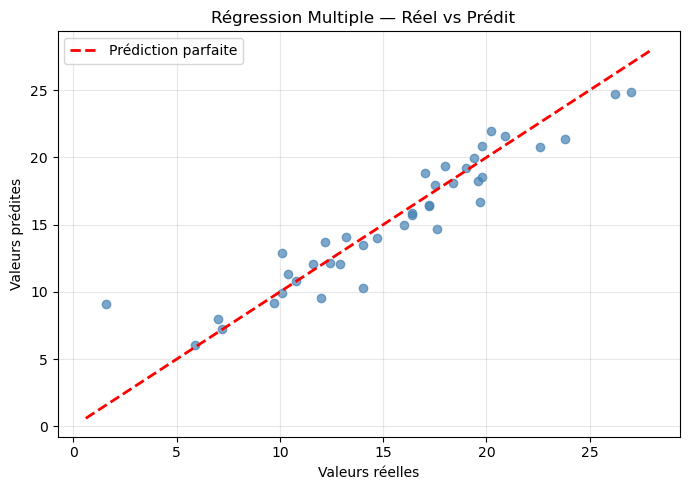

In [46]:
# Visualisation : Réel vs Prédit
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color="steelblue", alpha=0.7)
lims = [min(y_test.min(), y_pred.min()) - 1,
        max(y_test.max(), y_pred.max()) + 1]
plt.plot(lims, lims, "r--", linewidth=2, label="Prédiction parfaite")
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title(f"Régression Multiple — Réel vs Prédit  ")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#  <span style="color:blue">Régression polynomiale FROM SCRATCH</span>


In [47]:
# Régression POLYNOMIALE FROM SCRATCH
#  X = TV  →  y = Sales  (degré 2)
# X : variable explicative (budget TV)
# y : variable cible (ventes)
X = df["TV"].values
y = df["Sales"].values

# Split Train / Test (80% / 20%) 
# Fixer la seed pour reproductibilité
np.random.seed(42)
# Création des indices
indices = np.arange(len(X))
# Mélange aléatoire
np.random.shuffle(indices)

# 80% train / 20% test
split = int(0.8 * len(X))
# Séparation des données
X_train, X_test = X[indices[:split]], X[indices[split:]]
y_train, y_test = y[indices[:split]], y[indices[split:]]

print(f"Train : {len(X_train)} exemples | Test : {len(X_test)} exemples")


Train : 160 exemples | Test : 40 exemples


In [48]:

# Création des features polynomiales
# Principe :
# Transformer X en une matrice enrichie :
#
# Si degré = 2 :
# X_poly = [1, x, x²]
#
# Si degré = 3 :
# X_poly = [1, x, x², x³]
#
# Cela permet d'utiliser une régression linéaire
# MAIS sur des variables transformées → donc modèle non linéaire

DEGRE = 2   #  on peut changer ce paramètre pour tester d'autres modèles

# Construit la matrice :  [ 1,  x,  x²,  x³, ... ]
def creer_features_poly(X, degre):
   
    colonnes = [np.ones(len(X))]            # colonne de 1 (biais)
    for d in range(1, degre + 1):
        colonnes.append(X ** d)             # x, x², x³...
# Combiner toutes les colonnes en matrice
    return np.column_stack(colonnes)
# Application sur train et test
X_train_poly = creer_features_poly(X_train, DEGRE)
X_test_poly  = creer_features_poly(X_test,  DEGRE)



In [49]:
#  Calcul des coefficients (Équation Normale) 
#
#   Formule : β = (XᵀX)⁻¹ Xᵀy

beta = np.linalg.inv(X_train_poly.T @ X_train_poly) @ X_train_poly.T @ y_train

# Affichage des coefficients
print(f"Coefficients appris ")
for i, b in enumerate(beta):
    print(f"  b{i} = {b:.4f}")

# Prédictions
# Produit matriciel :
# y_pred = X_test_poly × β
y_pred = X_test_poly @ beta

# MSE : erreur quadratique moyenne
mse  = np.mean((y_test - y_pred) ** 2)

print(f"Résultats sur le Test")
print(f"MSE  = {mse:.4f}")

Coefficients appris 
  b0 = 5.9005
  b1 = 0.0801
  b2 = -0.0001
Résultats sur le Test
MSE  = 5.8380


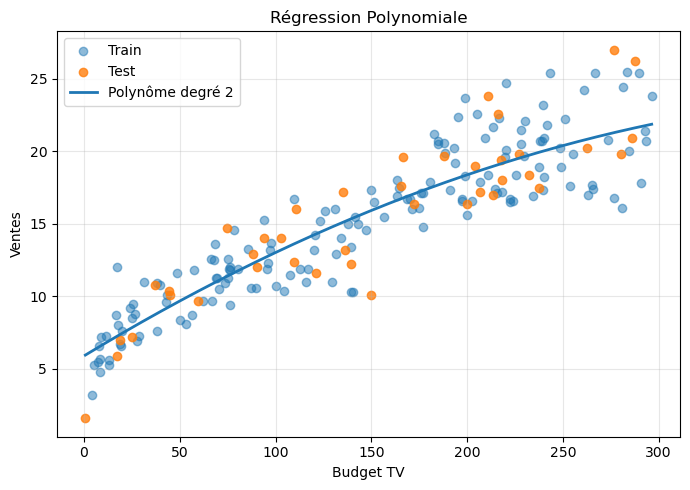

In [50]:
# Générer courbe lisse
x_line = np.linspace(X.min(), X.max(), 300)
x_line_poly = creer_features_poly(x_line, DEGRE)
y_line = x_line_poly @ beta

plt.figure(figsize=(7, 5))

# Points
plt.scatter(X_train, y_train, alpha=0.5, label="Train")
plt.scatter(X_test, y_test, alpha=0.8, label="Test")

# Courbe
plt.plot(x_line, y_line, linewidth=2,
         label=f"Polynôme degré {DEGRE}")

plt.xlabel("Budget TV")
plt.ylabel("Ventes")
plt.title("Régression Polynomiale")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#  <span style="color:blue">Logistic Regression</span>


Epoch 0 → Loss = 0.6931
Epoch 100 → Loss = 0.2676
Epoch 200 → Loss = 0.2190
Epoch 300 → Loss = 0.2004
Epoch 400 → Loss = 0.1907
Epoch 500 → Loss = 0.1848
Epoch 600 → Loss = 0.1809
Epoch 700 → Loss = 0.1782
Epoch 800 → Loss = 0.1762
Epoch 900 → Loss = 0.1747


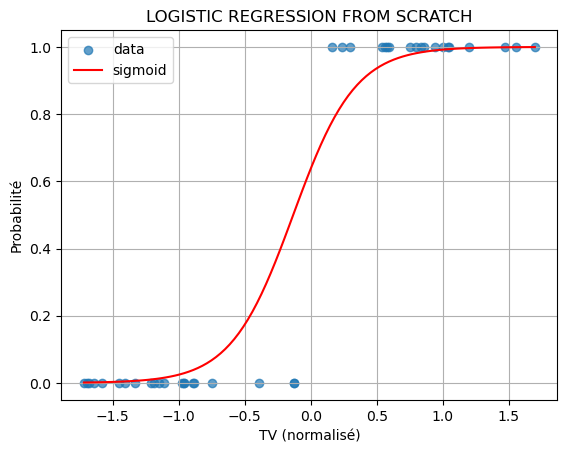

In [51]:

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

#  Données
# X : variable explicative (budget TV)
# y : variable cible transformée en classification
# Ici :
#   y = 1 si Sales > 15 (bonne vente)
#   y = 0 sinon
X = df["TV"].values
y = (df["Sales"] > 15).astype(int).values
# On divise les données en :
#   - 80% pour entraîner le modèle
#   - 20% pour tester le modèle
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#  Normalisation
# → Pour que les valeurs soient centrées (moyenne = 0)
# → Et avoir une échelle comparable (écart-type = 1)
# → Cela accélère la convergence du modèle

mean = x_train.mean()
std = x_train.std()

x_train = (x_train - mean) / std
x_test  = (x_test - mean) / std   

#  Initialisation

# a : poids (importance de TV)
# b : biais (valeur de base)
a = 0
b = 0

# hyperparamètres
lr = 0.1        # learning rate (vitesse d’apprentissage)
epochs = 1000   # nombre d’itérations

loss_history = []  # pour stocker l’évolution de l’erreur


# Sigmoid
# Transforme une valeur réelle en probabilité [0,1]
# Formule : S(z) = 1 / (1 + e^(-z))
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
# Entraînement
n = len(x_train)  # nombre d’exemples

for i in range(epochs):

    # Étape 1 : calcul du modèle linéaire
    # z = a*x + b
    z = a * x_train + b

    # Étape 2 : passer par sigmoid → probabilité
    y_pred = sigmoid(z)

    # loss
    # Cross-Entropy :
    # mesure l’erreur entre y réel et y prédit
    # On ajoute 1e-9 pour éviter log(0)
    loss = -np.mean(
        y_train*np.log(y_pred + 1e-9) +
        (1-y_train)*np.log(1-y_pred + 1e-9)
    )
    
    loss_history.append(loss)
    if i % 100 == 0:
        print(f"Epoch {i} → Loss = {loss:.4f}")
    # gradients
    # dérivée par rapport à a
    da = (1/n) * np.sum((y_pred - y_train) * x_train)

    # dérivée par rapport à b
    db = (1/n) * np.sum(y_pred - y_train)

    # update
     # on ajuste les paramètres pour réduire l’erreur
    a = a - lr * da
    b = b - lr * db

# GRAPHE 
# afficher les points réels
plt.scatter(x_test, y_test, label="data", alpha=0.7)

# créer une ligne continue pour tracer la courbe
x_line = np.linspace(x_test.min(), x_test.max(), 100)

# appliquer le modèle
z_line = a * x_line + b
y_line = sigmoid(z_line)

# tracer la courbe sigmoid
plt.plot(x_line, y_line, color="red", label="sigmoid")

plt.xlabel("TV (normalisé)")
plt.ylabel("Probabilité")
plt.title("LOGISTIC REGRESSION FROM SCRATCH")
plt.legend()
plt.grid()
plt.show()
